In [1]:
import pandas as pd

df_schulen = pd.read_csv(
    "../data/cleaned/oberschulen_oeffentlich_frei.csv",
    sep=";",
    dtype={"traegerschaft": "category"} # Die Spalte "traegerschaft" wird als Kategorie (category) eingelesen, um Speicherplatz zu sparen und die Verarbeitung zu optimieren.
) # oberschulen_oeffentlich_frei.csv einlesen und in einem DataFrame namens df_schulen speichern. Die Spalte "traegerschaft" wird als Kategorie (category) eingelesen, um Speicherplatz zu sparen und die Verarbeitung zu optimieren.

df_schulen.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   schuljahr               68 non-null     str     
 1   traegerschaft           68 non-null     category
 2   schulen                 68 non-null     int64   
 3   schueler_gesamt         68 non-null     int64   
 4   schueler_maennlich      68 non-null     int64   
 5   schueler_weiblich       68 non-null     int64   
 6   lehrpersonen_gesamt     68 non-null     int64   
 7   lehrpersonen_maennlich  68 non-null     int64   
 8   lehrpersonen_weiblich   68 non-null     int64   
dtypes: category(1), int64(7), str(1)
memory usage: 4.6 KB


# Erste Analysefrage: Wie hat sich die Zahl der öffentlichen und freien Oberschulen entwickelt?
Dazu werden die relevanten Daten in einen eigenen Dataframe df_schulzahlen abgespeichert:

In [2]:
df_schulzahlen = df_schulen[
    ["schuljahr", "traegerschaft", "schulen"]
].copy()

df_schulzahlen

,schuljahr,traegerschaft,schulen
0,1992/1993,öffentlich,661
1,1993/1994,öffentlich,660
2,1994/1995,öffentlich,661
3,1995/1996,öffentlich,657
4,1996/1997,öffentlich,653
...,...,...,...
63,2021/2022,frei,79
64,2022/2023,frei,82
65,2023/2024,frei,83
66,2024/2025,frei,86


Erstllen eines neuen Dataframe mit einem geänderten Format für eine verbesserte Darstellung zum Vergleich von "frei" und "öffentlich" pro Schuljahr:

In [3]:
df_schulzahlen_vergleich = df_schulzahlen.pivot(
    index="schuljahr",
    columns="traegerschaft",
    values="schulen"
)

df_schulzahlen_vergleich

traegerschaft,frei,öffentlich
schuljahr,,
1992/1993,1,661
1993/1994,2,660
1994/1995,2,661
1995/1996,2,657
1996/1997,4,653
1997/1998,5,646
1998/1999,6,642
1999/2000,7,636
2000/2001,8,624


Erste Visualisierung als Liniendiagramm:

<Axes: xlabel='schuljahr'>

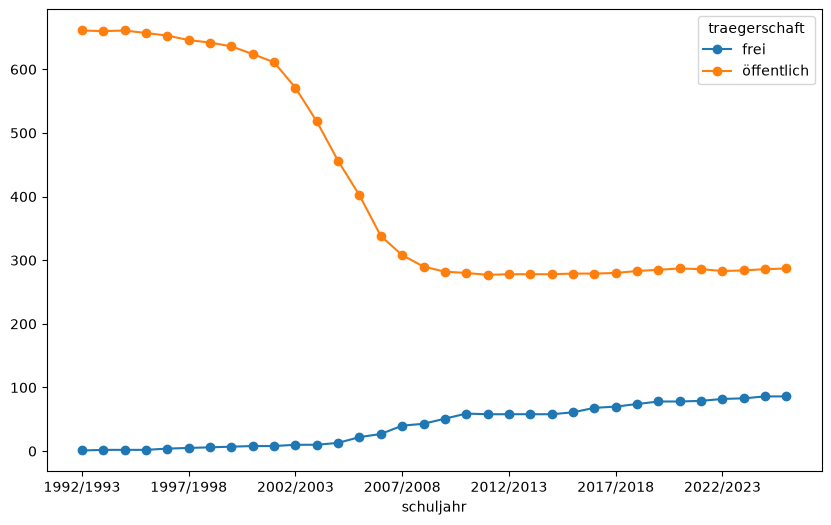

In [4]:
df_schulzahlen_vergleich.plot(
    figsize=(10, 6),
    marker="o"
)

Zahl der öffentlichen Schulen sinkt stark ab 2000, ab ca 2008 stabilisiert sich die Anzahl wieder. Die Zahl der freien Schulen steigt dagegen langfristig von einen sehr niedrigen Niveau. Trotzdem gibt es wesentlich mehr öffentliche als freie Schulen.

Anfangs- und Endbestand als Kennzahlen gegenüberstellen:

In [5]:
df_schulzahlen_vergleich.iloc[[0, -1]]

traegerschaft,frei,öffentlich
schuljahr,,
1992/1993,1,661
2025/2026,86,287


Jetzt die Werte als absolute Werte und als prozentuale Veränderung:

In [6]:
veraenderung_absolut = (
    df_schulzahlen_vergleich.iloc[-1]
    - df_schulzahlen_vergleich.iloc[0]
)

veraenderung_prozent = (
    veraenderung_absolut
    / df_schulzahlen_vergleich.iloc[0]
    * 100
)

veraenderung_absolut, veraenderung_prozent

(traegerschaft
 frei           85
 öffentlich   -374
 dtype: int64,
 traegerschaft
 frei          8500.000000
 öffentlich     -56.580938
 dtype: float64)

Ergebnis: Am Ende des betrachteten Zeitraums gibt es rund 57% weniger öffentliche Oberschulen als zu Beginn. Da der Zuwachs bei den freien Schulen 1.800% rein rechnerisch ergibt (da bei 1 beginnt und 2 schon 100% Zuwachs bedeutet), sollte man den absoluten Wert angeben, nämlich Zuwach +85 Schulen.

In [7]:
df_schulzahlen_veraenderung = df_schulzahlen_vergleich.diff()

df_schulzahlen_veraenderung

traegerschaft,frei,öffentlich
schuljahr,,
1992/1993,NaN,NaN
1993/1994,1.0,-1.0
1994/1995,0.0,1.0
1995/1996,0.0,-4.0
1996/1997,2.0,-4.0
1997/1998,1.0,-7.0
1998/1999,1.0,-4.0
1999/2000,1.0,-6.0
2000/2001,1.0,-12.0


Wann und wie groß waren die stärksten Veränderungen:

In [8]:
print("Stärkster Rückgang:")
print(df_schulzahlen_veraenderung.idxmin())
print("Stärkster Zuwachs:")
print(df_schulzahlen_veraenderung.idxmax())

Stärkster Rückgang:
traegerschaft
frei          2011/2012
öffentlich    2006/2007
dtype: str
Stärkster Zuwachs:
traegerschaft
frei          2007/2008
öffentlich    2018/2019
dtype: str


In [9]:
print("Stärkste negative Veränderung:")
print(df_schulzahlen_veraenderung.min())

print("\nStärkste positive Veränderung:")
print(df_schulzahlen_veraenderung.max())

Stärkste negative Veränderung:
traegerschaft
frei          -1.0
öffentlich   -64.0
dtype: float64

Stärkste positive Veränderung:
traegerschaft
frei          13.0
öffentlich     3.0
dtype: float64


# Zweite Analysefrage: Wie haben sich die Schülerzahlen an öffentlichen und freien Oberschulen entwickelt?
Zuerst den dafür relevanten Dataframe erstellen: df_schuelerzahlen aus df_schulen:

In [10]:
df_schuelerzahlen = df_schulen[
    ["schuljahr", "traegerschaft", "schueler_gesamt"]
].copy()

df_schuelerzahlen

,schuljahr,traegerschaft,schueler_gesamt
0,1992/1993,öffentlich,222966
1,1993/1994,öffentlich,216454
2,1994/1995,öffentlich,217118
3,1995/1996,öffentlich,220138
4,1996/1997,öffentlich,222004
...,...,...,...
63,2021/2022,frei,15259
64,2022/2023,frei,15948
65,2023/2024,frei,16652
66,2024/2025,frei,17281


Jetzt werden auch wieder die Daten in ein aunschaulicheres Format gebracht:

In [11]:
df_schuelerzahlen_vergleich = df_schuelerzahlen.pivot(
    index="schuljahr",
    columns="traegerschaft",
    values="schueler_gesamt"
)

df_schuelerzahlen_vergleich

traegerschaft,frei,öffentlich
schuljahr,,
1992/1993,81,222966
1993/1994,565,216454
1994/1995,181,217118
1995/1996,233,220138
1996/1997,604,222004
1997/1998,751,220349
1998/1999,889,217258
1999/2000,1082,213067
2000/2001,1228,207024


Visualisierung vom zeitlichem Verlauf der Schülerzahlen:

<Axes: xlabel='schuljahr'>

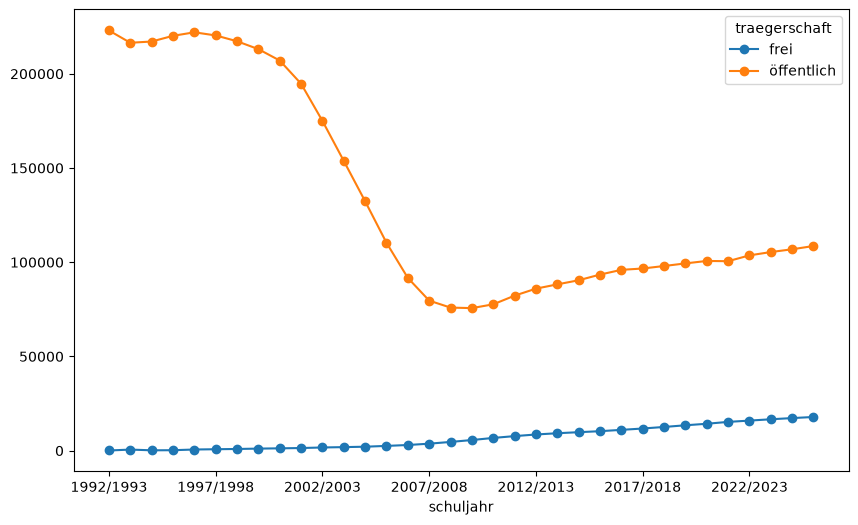

In [12]:
df_schuelerzahlen_vergleich.plot(
    figsize=(10, 6),
    marker="o"
)

Anfangs- und Endwerte:

In [13]:
df_schuelerzahlen_vergleich.iloc[[0, -1]]

traegerschaft,frei,öffentlich
schuljahr,,
1992/1993,81,222966
2025/2026,17864,108596


Absolute und prozentuale Veränderung (analog Anzahl der Schulen):

In [14]:
veraenderung_schueler_absolut = (
    df_schuelerzahlen_vergleich.iloc[-1]
    - df_schuelerzahlen_vergleich.iloc[0]
)

veraenderung_schueler_prozent = (
    veraenderung_schueler_absolut
    / df_schuelerzahlen_vergleich.iloc[0]
    * 100
)

veraenderung_schueler_absolut, veraenderung_schueler_prozent

(traegerschaft
 frei           17783
 öffentlich   -114370
 dtype: int64,
 traegerschaft
 frei          21954.320988
 öffentlich      -51.294816
 dtype: float64)

Jährliche Veränderung (Rückgang und Zuwachs) der Schüleranzahl:

In [15]:
df_schuelerzahlen_veraenderung = df_schuelerzahlen_vergleich.diff()

print("Stärkster Rückgang:")
print(df_schuelerzahlen_veraenderung.idxmin())
print(df_schuelerzahlen_veraenderung.min())

print("\nStärkster Zuwachs:")
print(df_schuelerzahlen_veraenderung.idxmax())
print(df_schuelerzahlen_veraenderung.max())

Stärkster Rückgang:
traegerschaft
frei          1994/1995
öffentlich    2005/2006
dtype: str
traegerschaft
frei           -384.0
öffentlich   -22031.0
dtype: float64

Stärkster Zuwachs:
traegerschaft
frei          2010/2011
öffentlich    2011/2012
dtype: str
traegerschaft
frei          1118.0
öffentlich    4599.0
dtype: float64


# Verbinden der beiden bisherigen Analysedaten für einen Vergleich der Veränderung der Anzahl der Schulen und der Anzahl der Schüler
Dafür neuen Dataframe erstellen und berechnen: Schüler/Schulen

In [16]:
df_schueler_je_schule = df_schulen[
    ["schuljahr", "traegerschaft", "schulen", "schueler_gesamt"]
].copy()

df_schueler_je_schule["schueler_je_schule"] = (
    df_schueler_je_schule["schueler_gesamt"]
    / df_schueler_je_schule["schulen"]
)

df_schueler_je_schule.head()

,schuljahr,traegerschaft,schulen,schueler_gesamt,schueler_je_schule
0,1992/1993,öffentlich,661,222966,337.316188
1,1993/1994,öffentlich,660,216454,327.960606
2,1994/1995,öffentlich,661,217118,328.468986
3,1995/1996,öffentlich,657,220138,335.065449
4,1996/1997,öffentlich,653,222004,339.975498


Um die Werte besser vergleichen zu können, wird wieder das Format geändert (und neuer Dataframe, Ergebnisse auf eine Kommastelle gerundet):

In [17]:
df_schueler_je_schule_vergleich = df_schueler_je_schule.pivot(
    index="schuljahr",
    columns="traegerschaft",
    values="schueler_je_schule"
)

df_schueler_je_schule_vergleich.round(1)

traegerschaft,frei,öffentlich
schuljahr,,
1992/1993,81.0,337.3
1993/1994,282.5,328.0
1994/1995,90.5,328.5
1995/1996,116.5,335.1
1996/1997,151.0,340.0
1997/1998,150.2,341.1
1998/1999,148.2,338.4
1999/2000,154.6,335.0
2000/2001,153.5,331.8


Visualisierung der Werte (Schüler/Schule)

<Axes: xlabel='schuljahr'>

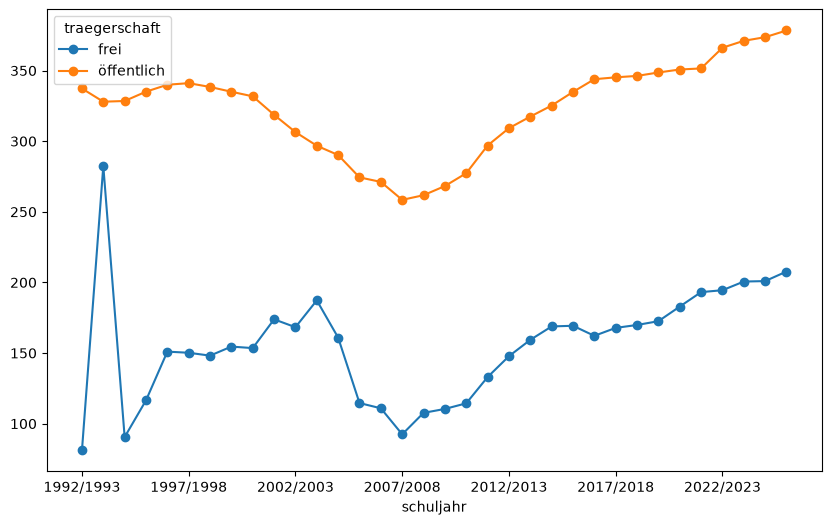

In [18]:
df_schueler_je_schule_vergleich.plot(
    figsize=(10, 6),
    marker="o"
)

Kennzahlen: Tiefpunkt und Endpunkt bestimmen:

In [19]:
print("Tiefpunkt:")
print(df_schueler_je_schule_vergleich.idxmin())
print(df_schueler_je_schule_vergleich.min().round(1))

print("\nEndstand 2025/2026:")
print(df_schueler_je_schule_vergleich.iloc[-1].round(1))

Tiefpunkt:
traegerschaft
frei          1992/1993
öffentlich    2007/2008
dtype: str
traegerschaft
frei           81.0
öffentlich    258.5
dtype: float64

Endstand 2025/2026:
traegerschaft
frei          207.7
öffentlich    378.4
Name: 2025/2026, dtype: float64
